In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
# XGBoost (learned from GPT)
from xgboost import XGBRegressor

In [159]:
# ==========================================
# 1. Data Loading & Cleaning
# ==========================================
def clean_stock_df(filename, ticker):
    """Load and clean individual stock data"""
    try:
        df = pd.read_csv(filename)
        # Drop the first row if it contains metadata/ticker name (common in some downloads)
        if df.iloc[0, 0] == ticker or df.iloc[0, 1] == ticker:
            df = df.drop(0)

        # Standardize columns
        df.columns = [c.lower() for c in df.columns]
        df['date'] = pd.to_datetime(df['date'])

        # Rename 'close' to unique ticker name
        df = df.rename(columns={'close': f'Close_{ticker}'})

        # Return only Date and Close Price (converted to numeric)
        df[f'Close_{ticker}'] = pd.to_numeric(df[f'Close_{ticker}'])
        return df[['date', f'Close_{ticker}']]
    except Exception as e:
        print(f"Error loading {ticker}: {e}")
        return None

# Load the 5 Tech Stocks
stocks = [
    ('AAPL', 'AAPL_2021-01-01_2026-01-31.csv'),
    ('AMZN', 'AMZN_2021-01-01_2026-01-31.csv'),
    ('GOOG', 'GOOG_2021-01-01_2026-01-31.csv'),
    ('MSFT', 'MSFT_2021-01-01_2026-01-31.csv'),
    ('NVDA', 'NVDA_2021-01-01_2026-01-31.csv')
]

dfs = [clean_stock_df(file, ticker) for ticker, file in stocks]

# Merge all stocks into one DataFrame
df_tech = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), dfs)

# Calculate "Tech Index" (Equal Weighted Average of the 5 stocks)
tech_cols = [c for c in df_tech.columns if 'Close_' in c]
df_tech['Tech_Index'] = df_tech[tech_cols].mean(axis=1)

# Load Gold Data
df_gold = pd.read_csv('gold_historical_data.csv')
df_gold['Date'] = pd.to_datetime(df_gold['Date'])
df_gold = df_gold.rename(columns={'Date': 'date', 'Close': 'Close_Gold'})
df_gold = df_gold[['date', 'Close_Gold']]

# Merge Tech + Gold
df_merged = pd.merge(df_tech, df_gold, on='date', how='outer')
df_merged = df_merged.sort_values('date')

# Forward Fill to handle trading holidays (Addressing Feedback)
df_merged = df_merged.ffill().dropna()

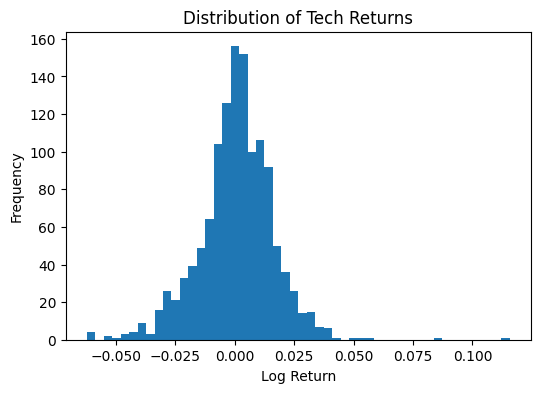

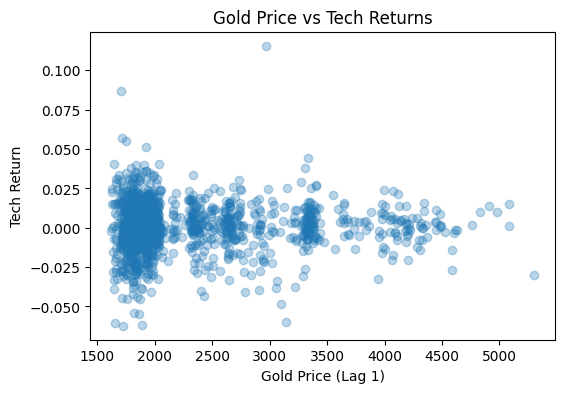

In [160]:
# ==========================================
# 2. Feature Engineering (Addressing Leakage)
# ==========================================
# Calculate Log Returns
df_merged['Log_Return_Tech'] = np.log(df_merged['Tech_Index'] / df_merged['Tech_Index'].shift(1))

# TARGET: Next Day's Return (t+1)
df_merged['Target_NextDay_Return'] = df_merged['Log_Return_Tech'].shift(-1)

# FEATURES: Lagged Data (t) - Strictly Past Info
df_merged['Feat_Tech_Return_Lag1'] = df_merged['Log_Return_Tech']
df_merged['Feat_Gold_Close_Lag1'] = df_merged['Close_Gold'].shift(1)
df_merged['Feat_Volatility_5'] = df_merged['Log_Return_Tech'].rolling(5).std().shift(1)

# Drop NaNs created by lagging
df_model = df_merged.dropna().copy()

# ==========================================
# Seasonality Features (Dinuka's Suggestion)
# ==========================================
df_model['day_of_year'] = df_model['date'].dt.dayofyear

df_model['sin_time'] = np.sin(2 * np.pi * df_model['day_of_year'] / 259)
df_model['cos_time'] = np.cos(2 * np.pi * df_model['day_of_year'] / 259)

# ==========================================
# EDA: Return Distribution
# ==========================================
plt.figure(figsize=(6,4))
plt.hist(df_model['Log_Return_Tech'], bins=50)
plt.title("Distribution of Tech Returns")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.show()

# ==========================================
# EDA: Gold vs Tech Relationship
# ==========================================
plt.figure(figsize=(6,4))
plt.scatter(df_model['Feat_Gold_Close_Lag1'], df_model['Log_Return_Tech'], alpha=0.3)
plt.title("Gold Price vs Tech Returns")
plt.xlabel("Gold Price (Lag 1)")
plt.ylabel("Tech Return")
plt.show()

In [161]:
# ==========================================
# 3. Train/Test Split (Ordered)
# ==========================================
train_size = int(len(df_model) * 0.8)
train_data = df_model.iloc[:train_size]
test_data = df_model.iloc[train_size:]

X_train = train_data[['Feat_Tech_Return_Lag1',
                      'Feat_Gold_Close_Lag1',
                      'Feat_Volatility_5',
                      'sin_time',
                      'cos_time']]
y_train = train_data['Target_NextDay_Return']
X_test = test_data[['Feat_Tech_Return_Lag1',
                    'Feat_Gold_Close_Lag1',
                    'Feat_Volatility_5',
                    'sin_time',
                    'cos_time']]
y_test = test_data['Target_NextDay_Return']

In [162]:
# ==========================================
# 4. Baseline Models
# ==========================================
# Baseline 1: Persistence (Naive) - Guessing tomorrow = today
y_pred_naive = X_test['Feat_Tech_Return_Lag1']

# Baseline 2: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Baseline 3: Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Baseline 4: XGBoost (from GPT)
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

--- Mid-Project Results ---
Persistence Baseline RMSE: 0.02261
Linear Regression RMSE:    0.01532
Random Forest RMSE:       0.01584
XGBoost RMSE:              0.02186
Best Model Improvement vs Baseline: 32.2%


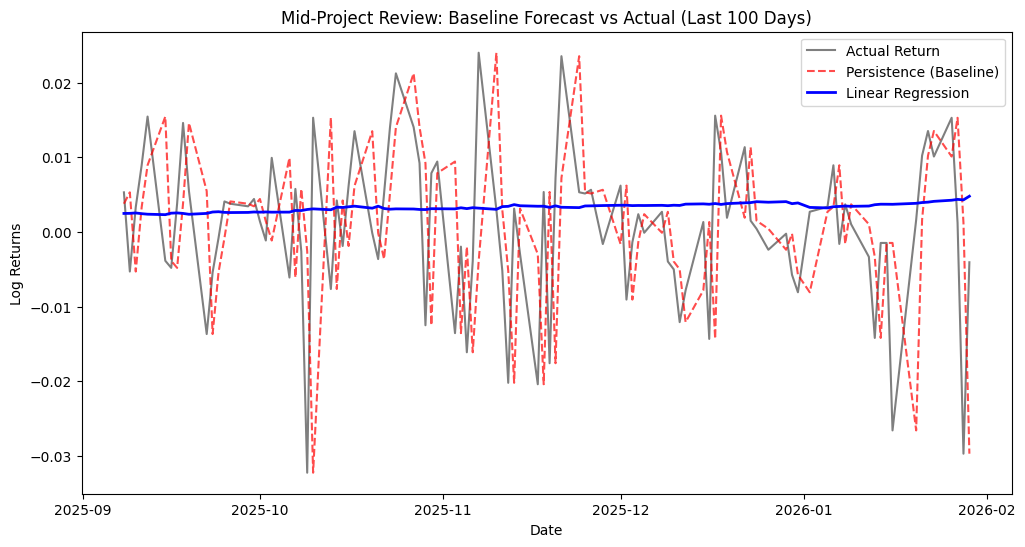

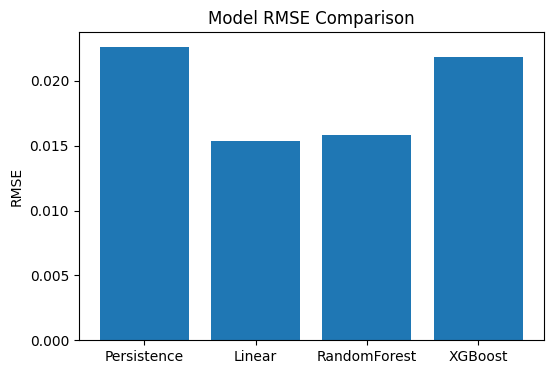

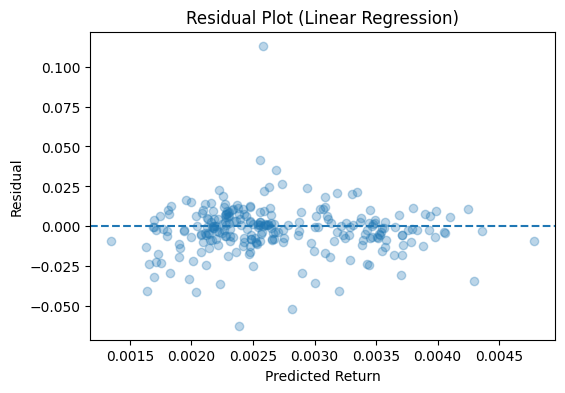

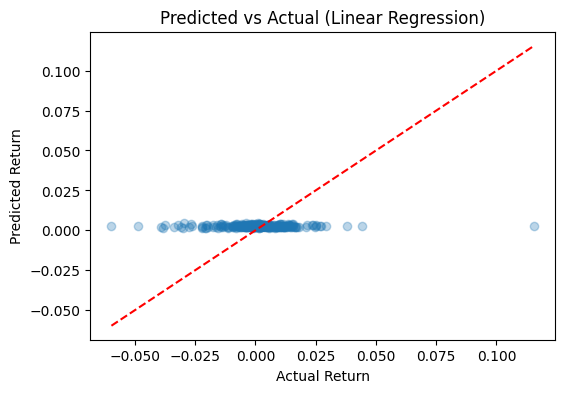

In [163]:
# ==========================================
# 5. Evaluation & Plotting
# ==========================================
rmse_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive))
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

best_rmse = min(rmse_lr, rmse_rf, rmse_xgb)

print(f"--- Mid-Project Results ---")
print(f"Persistence Baseline RMSE: {rmse_naive:.5f}")
print(f"Linear Regression RMSE:    {rmse_lr:.5f}")
print(f"Random Forest RMSE:       {rmse_rf:.5f}")
print(f"XGBoost RMSE:              {rmse_xgb:.5f}")
print(f"Best Model Improvement vs Baseline: {((rmse_naive - best_rmse)/rmse_naive)*100:.1f}%")

plt.figure(figsize=(12, 6))
# Plot only last 100 days for clarity
plt.plot(test_data['date'][-100:], y_test[-100:], label='Actual Return', color='black', alpha=0.5)
plt.plot(test_data['date'][-100:], y_pred_naive[-100:], label='Persistence (Baseline)', linestyle='--', color='red', alpha=0.7)
plt.plot(test_data['date'][-100:], y_pred_lr[-100:], label='Linear Regression', linestyle='-', color='blue', linewidth=2)
plt.title("Mid-Project Review: Baseline Forecast vs Actual (Last 100 Days)")
plt.xlabel("Date")
plt.ylabel("Log Returns")
plt.legend()
plt.show()

# ==========================================
# Model Comparison Plot
# ==========================================
models = ['Persistence', 'Linear', 'RandomForest', 'XGBoost']
rmse_values = [rmse_naive, rmse_lr, rmse_rf, rmse_xgb]

plt.figure(figsize=(6,4))
plt.bar(models, rmse_values)
plt.title("Model RMSE Comparison")
plt.ylabel("RMSE")
plt.show()

# ==========================================
# Residual Plot (Linear Regression)
# ==========================================
residuals = y_test - y_pred_lr

plt.figure(figsize=(6,4))
plt.scatter(y_pred_lr, residuals, alpha=0.3)
plt.axhline(0, linestyle='--')
plt.title("Residual Plot (Linear Regression)")
plt.xlabel("Predicted Return")
plt.ylabel("Residual")
plt.show()

# ==========================================
# Predicted vs Actual
# ==========================================
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_lr, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.title("Predicted vs Actual (Linear Regression)")
plt.xlabel("Actual Return")
plt.ylabel("Predicted Return")
plt.show()

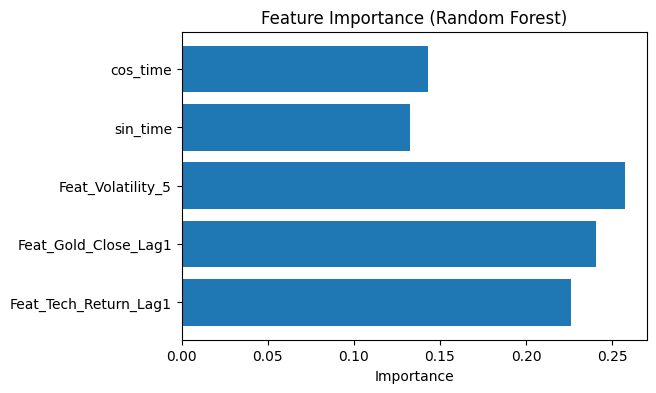

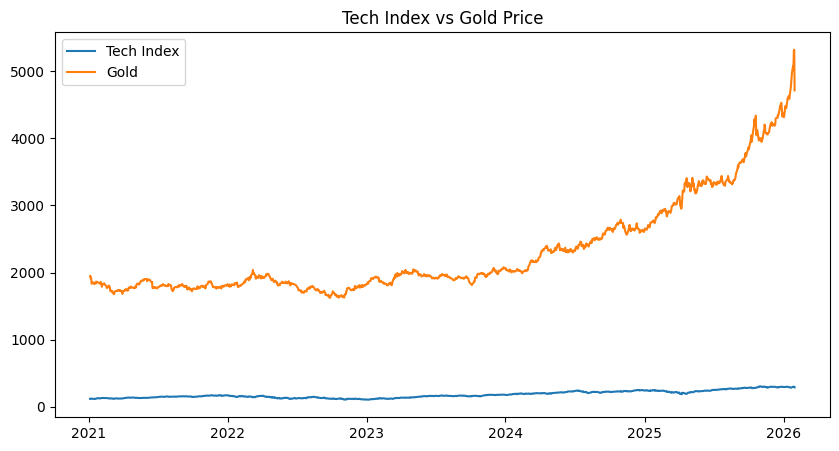

In [164]:
# ==========================================
# Feature Importance
# ==========================================
importances = rf.feature_importances_
features = X_train.columns

plt.figure(figsize=(6,4))
plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df_merged['date'], df_merged['Tech_Index'], label='Tech Index')
plt.plot(df_merged['date'], df_merged['Close_Gold'], label='Gold')
plt.legend()
plt.title("Tech Index vs Gold Price")
plt.show()

In [165]:
# ==========================================
# 6. Load Google Trends Data
# ==========================================
trends = pd.read_csv("time_series_US_20210101-0000_20260309-2230.csv")

trends['date'] = pd.to_datetime(trends['Time'])
trends = trends.drop(columns=['Time'])

trends.head()

,inflation,interest rate,recession,stock market,tech stocks,date
0,8,9,2,55,1,2021-01-01
1,10,11,2,48,1,2021-02-01
2,10,11,2,40,1,2021-03-01
3,10,11,2,32,0,2021-04-01
4,15,9,2,30,0,2021-05-01


In [166]:
# ==========================================
# 7. Merge Google Trends with Market Data
# ==========================================
df_merged = df_merged.merge(trends, on="date", how="left")
df_merged.head()

,date,Close_AAPL,Close_AMZN,Close_GOOG,Close_MSFT,Close_NVDA,Tech_Index,Close_Gold,Log_Return_Tech,Target_NextDay_Return,Feat_Tech_Return_Lag1,Feat_Gold_Close_Lag1,Feat_Volatility_5,inflation,interest rate,recession,stock market,tech stocks
0,2021-01-04,129.410004,159.331497,86.412003,217.690002,13.11350,121.191401,1944.699951,NaN,0.007119,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-05,131.009995,160.925507,87.045998,217.899994,13.40475,122.057248,1952.699951,0.007119,-0.025118,0.007119,1944.699951,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-06,126.599998,156.919006,86.764503,212.250000,12.61450,119.029602,1906.900024,-0.025118,0.024689,-0.025118,1952.699951,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-07,130.919998,158.108002,89.362503,218.289993,13.34400,122.004899,1912.300049,0.024689,0.007216,0.024689,1906.900024,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-08,132.050003,159.134995,90.360497,219.619995,13.27675,122.888448,1834.099976,0.007216,-0.016912,0.007216,1912.300049,NaN,NaN,NaN,NaN,NaN,NaN


In [167]:
# ==========================================
# 8. Fill Missing Google Trends Values
# ==========================================
df_merged = df_merged.fillna(method="ffill")
df_merged.head()

/tmp/ipykernel_231/1097836288.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_merged = df_merged.fillna(method="ffill")


,date,Close_AAPL,Close_AMZN,Close_GOOG,Close_MSFT,Close_NVDA,Tech_Index,Close_Gold,Log_Return_Tech,Target_NextDay_Return,Feat_Tech_Return_Lag1,Feat_Gold_Close_Lag1,Feat_Volatility_5,inflation,interest rate,recession,stock market,tech stocks
0,2021-01-04,129.410004,159.331497,86.412003,217.690002,13.11350,121.191401,1944.699951,NaN,0.007119,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-05,131.009995,160.925507,87.045998,217.899994,13.40475,122.057248,1952.699951,0.007119,-0.025118,0.007119,1944.699951,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-06,126.599998,156.919006,86.764503,212.250000,12.61450,119.029602,1906.900024,-0.025118,0.024689,-0.025118,1952.699951,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-07,130.919998,158.108002,89.362503,218.289993,13.34400,122.004899,1912.300049,0.024689,0.007216,0.024689,1906.900024,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-08,132.050003,159.134995,90.360497,219.619995,13.27675,122.888448,1834.099976,0.007216,-0.016912,0.007216,1912.300049,NaN,NaN,NaN,NaN,NaN,NaN


In [168]:
# ==========================================
# 9. Create Lag Features for Google Trends
# ==========================================
trend_cols = [
    "inflation",
    "interest rate",
    "recession",
    "stock market",
    "tech stocks"
]

for col in trend_cols:
    df_merged[col + "_lag1"] = df_merged[col].shift(1)

df_merged.head()

,date,Close_AAPL,Close_AMZN,Close_GOOG,Close_MSFT,Close_NVDA,Tech_Index,Close_Gold,Log_Return_Tech,Target_NextDay_Return,...,inflation,interest rate,recession,stock market,tech stocks,inflation_lag1,interest rate_lag1,recession_lag1,stock market_lag1,tech stocks_lag1
0,2021-01-04,129.410004,159.331497,86.412003,217.690002,13.11350,121.191401,1944.699951,NaN,0.007119,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-05,131.009995,160.925507,87.045998,217.899994,13.40475,122.057248,1952.699951,0.007119,-0.025118,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-06,126.599998,156.919006,86.764503,212.250000,12.61450,119.029602,1906.900024,-0.025118,0.024689,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-07,130.919998,158.108002,89.362503,218.289993,13.34400,122.004899,1912.300049,0.024689,0.007216,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-08,132.050003,159.134995,90.360497,219.619995,13.27675,122.888448,1834.099976,0.007216,-0.016912,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [169]:
# ==========================================
# 10. Rebuild Model Dataset with Trends
# ==========================================
df_model = df_merged.dropna().copy()
df_model.head()

,date,Close_AAPL,Close_AMZN,Close_GOOG,Close_MSFT,Close_NVDA,Tech_Index,Close_Gold,Log_Return_Tech,Target_NextDay_Return,...,inflation,interest rate,recession,stock market,tech stocks,inflation_lag1,interest rate_lag1,recession_lag1,stock market_lag1,tech stocks_lag1
20,2021-02-02,134.990005,169.000000,96.375504,239.509995,13.55675,130.686451,1830.500000,0.006439,0.009395,...,10.0,11.0,2.0,48.0,1.0,10.0,11.0,2.0,48.0,1.0
21,2021-02-03,133.940002,165.626495,103.503502,243.000000,13.53050,131.920100,1832.199951,0.009395,0.004737,...,10.0,11.0,2.0,48.0,1.0,10.0,11.0,2.0,48.0,1.0
22,2021-02-04,137.389999,166.550003,103.118500,242.009995,13.66425,132.546549,1788.900024,0.004737,0.003503,...,10.0,11.0,2.0,48.0,1.0,10.0,11.0,2.0,48.0,1.0
23,2021-02-05,136.759995,167.607498,104.900002,242.199997,13.59100,133.011698,1810.900024,0.003503,-0.000673,...,10.0,11.0,2.0,48.0,1.0,10.0,11.0,2.0,48.0,1.0
24,2021-02-08,136.910004,166.147003,104.645500,242.470001,14.43875,132.922252,1831.900024,-0.000673,-0.001721,...,10.0,11.0,2.0,48.0,1.0,10.0,11.0,2.0,48.0,1.0


In [170]:
# ==========================================
# Recreate Seasonality Features
# ==========================================

df_model['day_of_year'] = df_model['date'].dt.dayofyear

df_model['sin_time'] = np.sin(2 * np.pi * df_model['day_of_year'] / 259)
df_model['cos_time'] = np.cos(2 * np.pi * df_model['day_of_year'] / 259)

In [171]:
# ==========================================
# 11. Define Features (with Google Trends)
# ==========================================
features = [
    'Feat_Tech_Return_Lag1',
    'Feat_Gold_Close_Lag1',
    'Feat_Volatility_5',
    'sin_time',
    'cos_time',

    'inflation_lag1',
    'interest rate_lag1',
    'recession_lag1',
    'stock market_lag1',
    'tech stocks_lag1'
]

In [172]:
# ==========================================
# 12. Train/Test Split
# ==========================================
train_size = int(len(df_model) * 0.8)

train_data = df_model.iloc[:train_size]
test_data = df_model.iloc[train_size:]

X_train = train_data[features]
y_train = train_data['Target_NextDay_Return']

X_test = test_data[features]
y_test = test_data['Target_NextDay_Return']

In [173]:
# ==========================================
# 13. Retrain Models with Google Trends
# ==========================================
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [174]:
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("--- Final Model Results ---")
print("Linear RMSE:", rmse_lr)
print("Random Forest RMSE:", rmse_rf)
print("XGBoost RMSE:", rmse_xgb)

--- Final Model Results ---
Linear RMSE: 0.015247001578197425
Random Forest RMSE: 0.01590882571963791
XGBoost RMSE: 0.02097272392858356


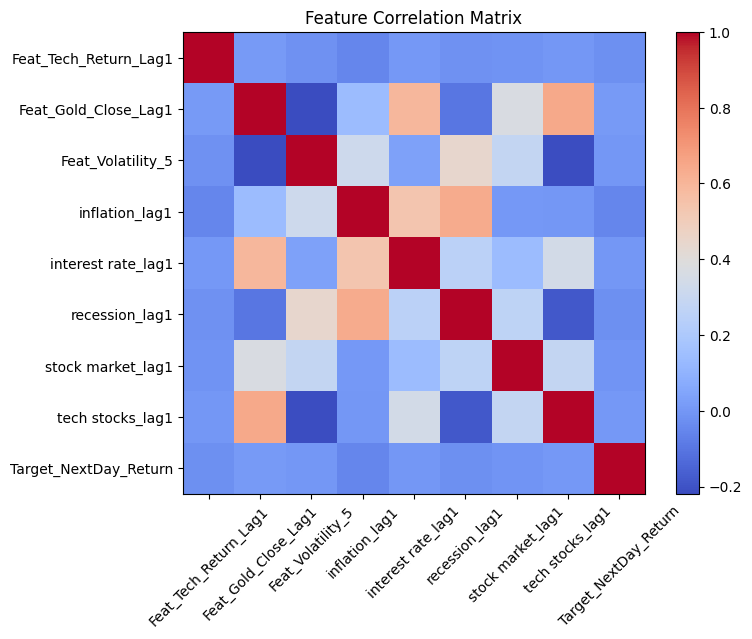

In [175]:
# ==========================================
# Correlation Analysis
# ==========================================
corr_cols = [
    'Feat_Tech_Return_Lag1',
    'Feat_Gold_Close_Lag1',
    'Feat_Volatility_5',
    'inflation_lag1',
    'interest rate_lag1',
    'recession_lag1',
    'stock market_lag1',
    'tech stocks_lag1',
    'Target_NextDay_Return'
]

corr_matrix = df_model[corr_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)

plt.title("Feature Correlation Matrix")
plt.show()

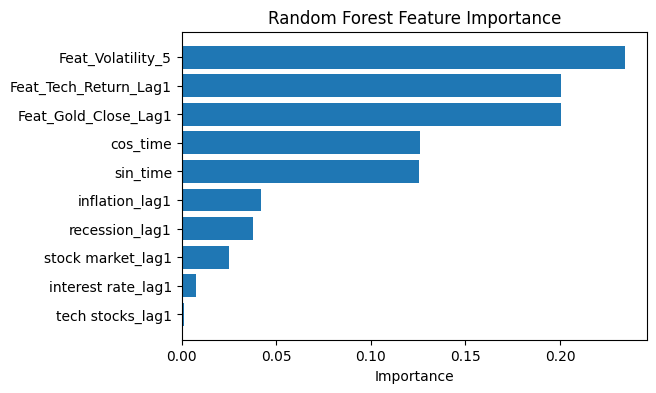

In [176]:
# ==========================================
# Sorted Feature Importance
# ==========================================
importances = rf.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

importance_df = importance_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(6,4))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

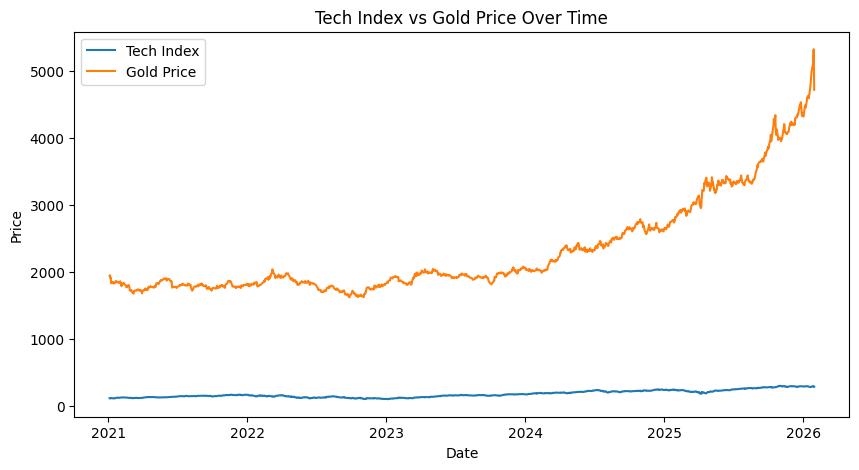

In [177]:
# ==========================================
# Market Trends Visualization
# ==========================================
plt.figure(figsize=(10,5))

plt.plot(df_merged['date'], df_merged['Tech_Index'], label='Tech Index')
plt.plot(df_merged['date'], df_merged['Close_Gold'], label='Gold Price')

plt.legend()
plt.title("Tech Index vs Gold Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

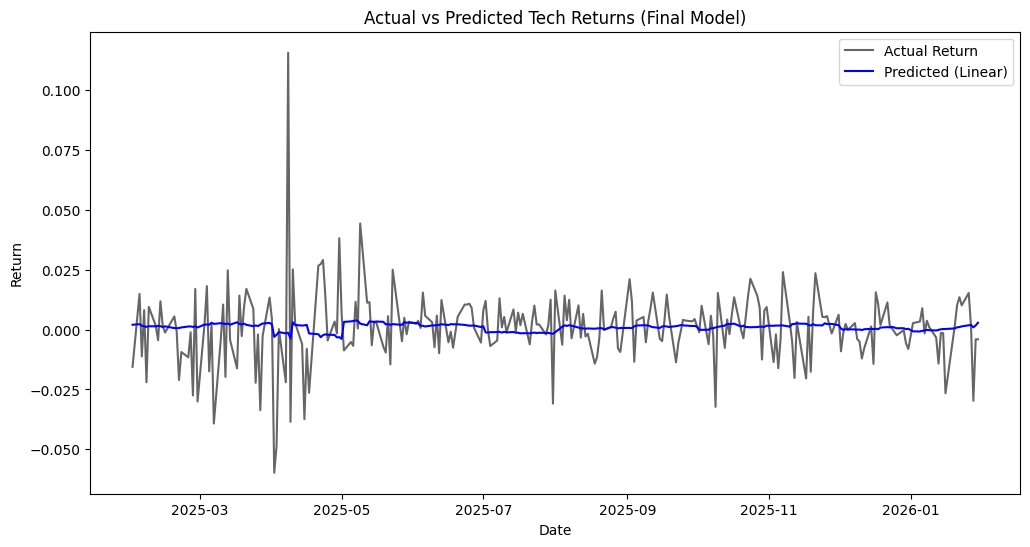

In [178]:
# ==========================================
# Final Model: Actual vs Predicted
# ==========================================

plt.figure(figsize=(12,6))

plt.plot(test_data['date'], y_test, label='Actual Return', color='black', alpha=0.6)
plt.plot(test_data['date'], y_pred_lr, label='Predicted (Linear)', color='blue')

plt.title("Actual vs Predicted Tech Returns (Final Model)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()

plt.show()